In [1]:
import torch
import os
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertConfig, BertForSequenceClassification
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from transformers import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from typing import Literal

模型运行在 cuda:0 上


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


数据集统计： label
0    64
1    29
Name: count, dtype: int64


  0%|          | 0/200 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]

,文本内容,真实标签,预测标签,预测是否正确
0,存在交通违法行为。,1,1,True
1,有交通违法行为。,1,1,True
2,存在交通违法行为。,1,1,True
3,存在交通违法行为。,1,1,True
4,无法判断是否存在交通违法行为。,1,1,True
...,...,...,...,...
88,雨雪天行驶行为合规。,0,0,True
89,车辆会车操作合法。,0,0,True
90,交通行为完全合法。,0,0,True
91,未检出任何交通违法。,0,0,True


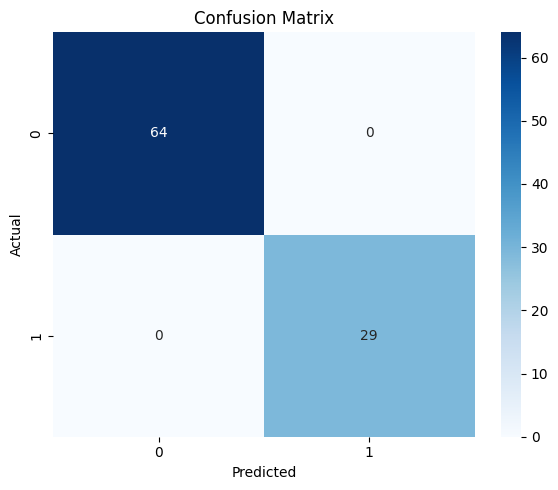

分类头参数已保存到: classifier.pth

--------------------- 人工测试模式（输入q退出）---------------------


输入要判断的内容:  存在交通违法行为


预测结果: 1


输入要判断的内容:  无交通违法行为


预测结果: 0


输入要判断的内容:  有交通违法行为


预测结果: 1


输入要判断的内容:  不存在交通违法行为


预测结果: 0


输入要判断的内容:  q


In [9]:
PRETRAINED_PATH = 'bert-base-chinese'

class LastClassifier(nn.Module):
    def __init__(self, hidden_dim=768, output_dim=2):
        super().__init__()
        self.fn1 = nn.Linear(768, hidden_dim)
        self.ac1 = nn.Hardtanh()
        self.fn2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.fn1(x)
        out = self.ac1(out)
        out = self.fn2(out)
        return out

def transform(text, tokenizer, max_len=32):
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors=None
    )
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']
    token_type_ids = inputs['token_type_ids']

    return {
        'input_text': text,
        'input_ids': torch.tensor(input_ids, dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
    }
    
def batch_transform(text, tokenizer, max_len=32):
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors=None,
    )
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']
    token_type_ids = inputs['token_type_ids']

    return {
        'input_text': text,
        'input_ids': torch.tensor(input_ids, dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
    }

class TextDataset(Dataset):
    def __init__(self, data, label, tokenizer, max_len=512):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.data = data
        self.labels = label

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]
        label = self.labels[idx]
        
        out = transform(text, self.tokenizer, self.max_len)
        out['label'] = torch.tensor(label, dtype=torch.long)
        return out

class DeployDataset(Dataset):
    def __init__(self, pf_data:pd.DataFrame, tokenizer, max_len=512):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.data = pf_data
        
        self.length = len(pf_data.values.tolist())

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        text = str(self.data.iloc[idx]['content'])
        if text == 'nan' or text == 'None' or text == 'none' or text == 'NAN' or text is None or not text:
            text = 'nan'
        out = transform(text, self.tokenizer, self.max_len)
        
        out['user_id'] = self.data.iloc[idx]['user_id']
        out['nickname'] = self.data.iloc[idx]['nickname']
        return out

def train_bert_model(
    episode = 28,
    batch_size = 32,
    max_len = 50,
    learning_rate = 2e-6,
    weight_decay = 1e-3,
    num_labels=2,
    dropout_prop=0.3,
    pretraind_path='bert-base-chinese',
    save_path=os.path.join('classifier_only.pth'),
    dataset=os.path.join('bert_dataset.txt'),
    human_test=False
):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"模型运行在 {device} 上")

    tokenizer = BertTokenizer.from_pretrained(pretraind_path)
    config = BertConfig.from_pretrained(
        pretraind_path,
        num_labels=num_labels,
        hidden_dropout_prob=dropout_prop
    )
    model = BertForSequenceClassification.from_pretrained(pretraind_path, config=config).to(device)
    model.classifier = LastClassifier(hidden_dim=768, output_dim=num_labels).to(device)

    ad_data = []
    ad_labels = []

    with open(dataset, 'r', encoding='utf-8') as f:
        for line in f.readlines():
            part = line.strip().split('\t')
            if len(part) < 2:
                continue
            ad_labels.append(int(part[0]))
            ad_data.append(part[1])

    print("数据集统计：", pd.DataFrame({"label": ad_labels, "data": ad_data})['label'].value_counts())

    train_dataset = TextDataset(ad_data, ad_labels, tokenizer, max_len=max_len)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    model.train()
    with tqdm(range(episode)) as tbar:
        for epoch in tbar:
            losses = []
            optimizer.zero_grad()
        
            for batch in train_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                token_type_ids = batch['token_type_ids'].to(device)
                labels = batch['label'].to(device)

                out = model(input_ids, attention_mask, token_type_ids)
                loss = criterion(out.logits, labels)
                loss.backward()
                optimizer.step()

                losses.append(loss.item())
                tbar.set_postfix(loss=np.mean(losses))

    valid_texts = []
    valid_true_labels = []
    with open(dataset, 'r', encoding='utf-8') as f:
        for line in f.readlines():
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                valid_texts.append(parts[1])
                valid_true_labels.append(int(parts[0]))

    valid_dataset = TextDataset(valid_texts, valid_true_labels, tokenizer, max_len=max_len)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_content, all_true_labels, all_predictions = [], [], []
    with torch.no_grad():
        with tqdm(valid_loader, desc='Validating') as tbar:
            for batch in tbar:
                all_content.extend(batch['input_text'])
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                token_type_ids = batch['token_type_ids'].to(device)
                labels = batch['label'].to(device)

                out = model(input_ids, attention_mask, token_type_ids)
                preds = torch.argmax(out.logits, dim=1).cpu().numpy()
                all_true_labels.extend(labels.cpu().numpy())
                all_predictions.extend(preds)

    result_df = pd.DataFrame({
        '文本内容': all_content,
        '真实标签': all_true_labels,
        '预测标签': all_predictions,
        '预测是否正确': np.array(all_true_labels) == np.array(all_predictions)
    })

    display(result_df)

    cm = confusion_matrix(all_true_labels, all_predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    torch.save(model.state_dict(), save_path)
    print(f"分类头参数已保存到: {save_path}")

    if human_test:
        print("\n--------------------- 人工测试模式（输入q退出）---------------------")
        with torch.no_grad():
            while True:
                text = input("输入要判断的内容: ")
                if text in ['', 'q', 'Q']:
                    break
                inputs = transform(text, tokenizer=tokenizer, max_len=max_len)
    
                input_ids = inputs['input_ids'].clone().detach().unsqueeze(0).to(device)
                attention_mask = inputs['attention_mask'].clone().detach().unsqueeze(0).to(device)
                token_type_ids = inputs['token_type_ids'].clone().detach().unsqueeze(0).to(device)
    
                out = model(input_ids, attention_mask, token_type_ids)
                predicted = torch.argmax(out.logits, 1).cpu().numpy()[0]
                print(f"预测结果: {predicted}")


if __name__ == '__main__':
    train_bert_model(
        episode = 200,
        batch_size = 10,
        max_len = 8,
        learning_rate = 2e-6,
        weight_decay = 1e-3,
        num_labels=2,
        dropout_prop=0.3,
        pretraind_path='bert-base-chinese',
        save_path=os.path.join('classifier.pth'),
        dataset=os.path.join('bert_dataset.txt'),
        human_test=True
    )